#### ANÁLISE BRASIL

In [2]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
import os
from tabulate import tabulate
from datetime import datetime
from dbfread import DBF
import openpyxl
import geopandas as gpd
import ssl
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
import shutil

# Filtro de data
data_analise = '05/07/2026'

In [3]:
# Criar pasta para salvar os arquivos
nome_pasta = f'Chikungunya_brasil_graficos'
local_salvar = os.getcwd()
local_pasta = os.path.join(local_salvar, nome_pasta)

if not os.path.exists(local_pasta):
    os.makedirs(local_pasta)
    print(f"Pasta {nome_pasta} criada!")
else:
    print(f"A pasta {nome_pasta} já existe. Os arquivos serão salvos nela.")

A pasta Chikungunya_brasil_graficos já existe. Os arquivos serão salvos nela.


In [ ]:
# Processamento da base do SINAN
# 1. Os arquivos DBF serão convertidos para xlsx
# 2. Após a conversão serão automaticamente excluídos
# 3. Os arquivos xlsx serão concatenados em um arquivo único
# 4. Serão removidas colunas sem utilidade para análise
# 5. Serão criados os arquivos de casos notificados e prováveis
        # Os dados serão filtrados para um recorte de oito semanas, a partir da semana atual
# 6. Processamento da base do GAL
# 7. Transformação da tabela para um formato vertical e reorganização das métricas
        # Os dados serão filtrados para um recorte de oito semanas, a partir da semana atual

# CONVERSÃO DE DBF PARA XLSX E EXCLUSÃO DO DBF

# Obter o caminho absoluto do diretório atual
caminho_arquivos = os.path.abspath('')

# Listar todos os arquivos da pasta
arquivos_na_pasta = os.listdir(caminho_arquivos)

# Filtrar apenas arquivos que sejam .dbf (ou .DBF) e que comecem com 'CHIKON_'
arquivos_dbf = [
    arq for arq in arquivos_na_pasta 
    if arq.lower().endswith('.dbf') and arq.upper().startswith('CHIKON_')
]

if len(arquivos_dbf) > 0:
    print(f"Encontrados {len(arquivos_dbf)} arquivos DBF para converter.")
    
    for arquivo in arquivos_dbf:
        caminho_completo_dbf = os.path.join(caminho_arquivos, arquivo)
        
        # Cria o nome do novo arquivo trocando a extensão para .xlsx
        nome_sem_extensao = os.path.splitext(arquivo)[0]
        caminho_completo_xlsx = os.path.join(caminho_arquivos, f"{nome_sem_extensao}.xlsx")
        
        print(f"Convertendo: {arquivo}")
        
        try:
            # Lendo o DBF e convertendo para Excel
            tabela_dbf = DBF(caminho_completo_dbf, encoding='iso-8859-1')
            df_temp = pd.DataFrame(iter(tabela_dbf))
            df_temp.to_excel(caminho_completo_xlsx, index=False)
            
            # Se chegou até aqui sem dar erro, exclui o arquivo DBF original
            os.remove(caminho_completo_dbf)
            print(f"{nome_sem_extensao}.xlsx salvo com sucesso. Arquivo DBF excluído.")
            
        except Exception as e:
            print(f"Erro na conversão do arquivo {arquivo}. Motivo: {e}")
else:
    print("Nenhum arquivo DBF encontrado para conversão!\nVerificar a pasta!")

print("-" * 50)

# CONCATENAÇÃO ARQUIVOS XLSX E LIMPEZA DOS DADOS

# Atualizar a lista de arquivos na pasta
arquivos_atualizados = os.listdir(caminho_arquivos)

# Buscar todos os arquivos .xlsx que comecem com 'CHIKON_'
arquivos_excel = [
    arq for arq in arquivos_atualizados 
    if arq.lower().endswith('.xlsx') and arq.upper().startswith('CHIKON_')
]

if len(arquivos_excel) > 0:
    print(f"Concatenando {len(arquivos_excel)} arquivos")
    
    dfs = []
    
    # Ler cada arquivo e adicionar o DataFrame à lista
    for arquivo in arquivos_excel:
        caminho_completo = os.path.join(caminho_arquivos, arquivo)
        df_estados = pd.read_excel(caminho_completo)
        dfs.append(df_estados)
    
    # Concatenar todos os DataFrames em um único DataFrame
    df_final = pd.concat(dfs, ignore_index=True)

    print('Arquivos concatenados com sucesso!')
    
    # Remover colunas desnecessárias
    colunas_para_remover = [
        'SOUNDEX', 'ID_DISTRIT', 'ID_GEO1', 'ID_GEO2', 'DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA',
        'ACIDO_PEPT', 'AUTO_IMUNE', 'DT_CHIK_S1', 'DT_CHIK_S2', 'DT_PRNT', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 
        'HOSPITALIZ', 'DT_INTERNA', 'UF', 'MUNICIPIO', 'HOSPITAL', 'DDD_HOSP', 'TEL_HOSP', 'TPAUTOCTO', 'COUFINF', 
        'COPAISINF', 'COMUNINF', 'CODISINF', 'CO_BAINF', 'NOBAIINF', 'DOENCA_TRA', 'CLINC_CHIK', 'ALRM_HIPOT', 
        'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 
        'DT_ALRM', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 
        'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO', 
        'DT_GRAV', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 
        'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'NU_LOTE_I', 'NDUPLIC_N', 'DT_TRANSUS', 
        'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM', 'DT_TRANSRS', 'DT_TRANSSE', 'NU_LOTE_V', 'NU_LOTE_H', 'CS_FLXRET', 
        'FLXRECEBI', 'IDENT_MICR', 'MIGRADO_W', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'ID_PAIS', 'ID_OCUPA_N', 
        'DT_SORO', 'DT_NS1', 'DT_VIRAL', 'SOROTIPO', 'RESUL_VI_N', 'HISTOPA_N', 'IMUNOH_N', 'TP_SISTEMA', 'TP_NOT', 
        'CS_ESCOL_N', 'CS_GESTANT', 'DS_OBS', 'DT_ALARM', 'NM_LOGRADO', 'NU_LOTE_N', 'ID_LOGRADO', 'NM_REFEREN', 'NU_DDD_TEL', 'NU_TELEFON',
        'IN_VINCULA', 'FONETICA_N'
    ]
    
    colunas_existentes = [col for col in colunas_para_remover if col in df_final.columns]
    df_final = df_final.drop(columns=colunas_existentes)
    
    # Criação da coluna SE
    if 'SEM_PRI' in df_final.columns:
        posicao_sem_pri = df_final.columns.get_loc('SEM_PRI')    
        valores_se = df_final['SEM_PRI'].astype(str).str[-2:]
        df_final.insert(loc=posicao_sem_pri + 1, column='SE', value=valores_se)
    
    # Filtro para oito semanas, a partir da semana atual
    se_atual = df_final['SE'].max()
    df_final['SE'] = pd.to_numeric(df_final['SE'], errors='coerce')
    se_atual = df_final['SE'].max()
    semanas_analise = se_atual - 7
    
    df_final_filtrado = df_final[df_final['SE'].between(semanas_analise, se_atual)]

    # CRIAR ARQUIVO DE CASOS NOTIFICADOS
    output_file_path = os.path.join(caminho_arquivos, 'chik_brasil_notificados_2026.xlsx')
    df_final_filtrado.to_excel(output_file_path, index=False)
    
    print('Arquivo com casos notificados criado com sucesso!')

    # CRIAR ARQUIVO DE CASOS PROVAVEIS
    df_provaveis = pd.read_excel('chik_brasil_notificados_2026.xlsx')

    # Filtragem do dataframe
    df_provaveis_chik = df_provaveis[df_provaveis['CLASSI_FIN'] != 5]

    df_provaveis_chik.to_excel('chik_brasil_provaveis_2026.xlsx', index= False)

    print('Arquivo com casos provaveis criado com sucesso!')

# ======================================================== #

# Processamento da base do GAL
# Carregar a aba mais detalhada (Municípios)
df_gal_bruto = pd.read_excel('chikungunya_analise_RTPCR.xlsx', sheet_name='Chikungunya_por_Municipio_RTPCR')

# Desfazer (Melt) a tabela e transformar as dezenas de colunas em linhas
df_melt = df_gal_bruto.melt(
    id_vars=['paciente_municipio_ibge', 'paciente_municipio'], 
    var_name='Coluna_Original', 
    value_name='Valor'
)

# Extrair a Semana (SE) e o Tipo de Métrica (exames, positivos, etc)
# Exemplo: de '2026_SE01_exames' extrai '1' e 'exames'
df_melt['SE'] = df_melt['Coluna_Original'].str.extract(r'SE(\d+)').fillna(0)
df_melt['SE'] = df_melt['SE'].astype(int)
df_melt['Metrica'] = df_melt['Coluna_Original'].apply(lambda x: x.split('_')[-1])

# Reorganizar para ter as métricas como colunas arrumadas
df_gal_brasil = df_melt.pivot_table(
    index=['paciente_municipio_ibge', 'paciente_municipio', 'SE'],
    columns='Metrica',
    values='Valor',
    aggfunc='sum'
).reset_index()

# Limpeza e Cálculos Finais
# Preencher possíveis vazios com 0 e remover o nome do eixo de colunas
df_gal_brasil = df_gal_brasil.fillna(0)
df_gal_brasil.columns.name = None 

# Renomear as colunas para ficar elegante no seu código
df_gal_final = df_gal_brasil.rename(columns={
    'paciente_municipio_ibge': 'IBGE',
    'paciente_municipio': 'Municipio',
    'exames': 'Exames_Realizados',
    'positivos': 'Casos_Positivos'
})

# Filtrar para as últimas oito semanas, a partir da semana atual
se_atual = df_gal_final['SE'].max()
df_gal_final['SE'] = pd.to_numeric(df_gal_final['SE'], errors='coerce')
semanas_analise = se_atual - 7
df_gal_final = df_gal_final[df_gal_final['SE'].between(semanas_analise, se_atual)]

# Calculo de taxa de positividade
df_gal_final['Positividade_%'] = np.where(
    df_gal_final['Exames_Realizados'] > 0, 
    (df_gal_final['Casos_Positivos'] / df_gal_final['Exames_Realizados']) * 100, 
    0
)

# Criar a coluna de código da UF para filtragem
df_gal_final['UF_COD'] = (df_gal_final['IBGE']//10000).astype(int)
df_gal_final['UF_COD'] = pd.to_numeric(df_gal_final['UF_COD'], errors='coerce')

df_gal_final.to_excel('chik_brasil_gal_2026.xlsx')

print("Arquivo GAL criado com sucesso!")

# ======================================================== #

# Carregar base de dados para casos por unidade da federação
df_sinan = pd.read_excel('chik_brasil_provaveis_2026.xlsx')

# Mapeamento das unidades federativas por código IBGE
mapa_uf = {
    11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
    21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL', 28: 'SE', 29: 'BA',
    31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP', 41: 'PR', 42: 'SC', 43: 'RS', 50: 'MS', 51: 'MT', 
    52: 'GO', 53: 'DF'
}

# Carregar base dos municípios brasileiros
df_municipios = pd.read_excel('municipios_brasil.xlsx')

print('Base de municípios carregada com sucesso!')

print('-' * 50)
print('Bases de dados criadas com sucesso')

Nenhum arquivo DBF encontrado para conversão!
Verificar a pasta!
--------------------------------------------------
Concatenando 27 arquivos
Arquivos concatenados com sucesso!
Arquivo com casos notificados criado com sucesso!
Arquivo com casos provaveis criado com sucesso!
Arquivo GAL criado com sucesso!
Base de municípios carregada com sucesso!


Arquivo GAL criado com sucesso!


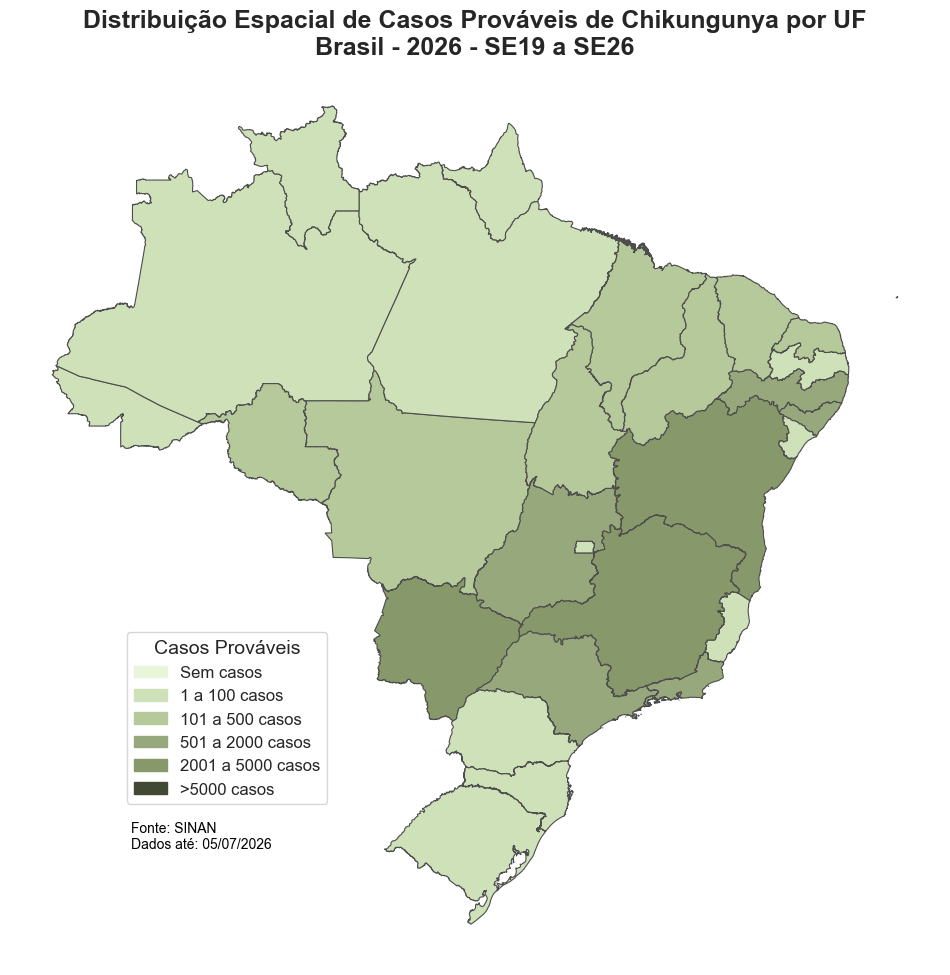

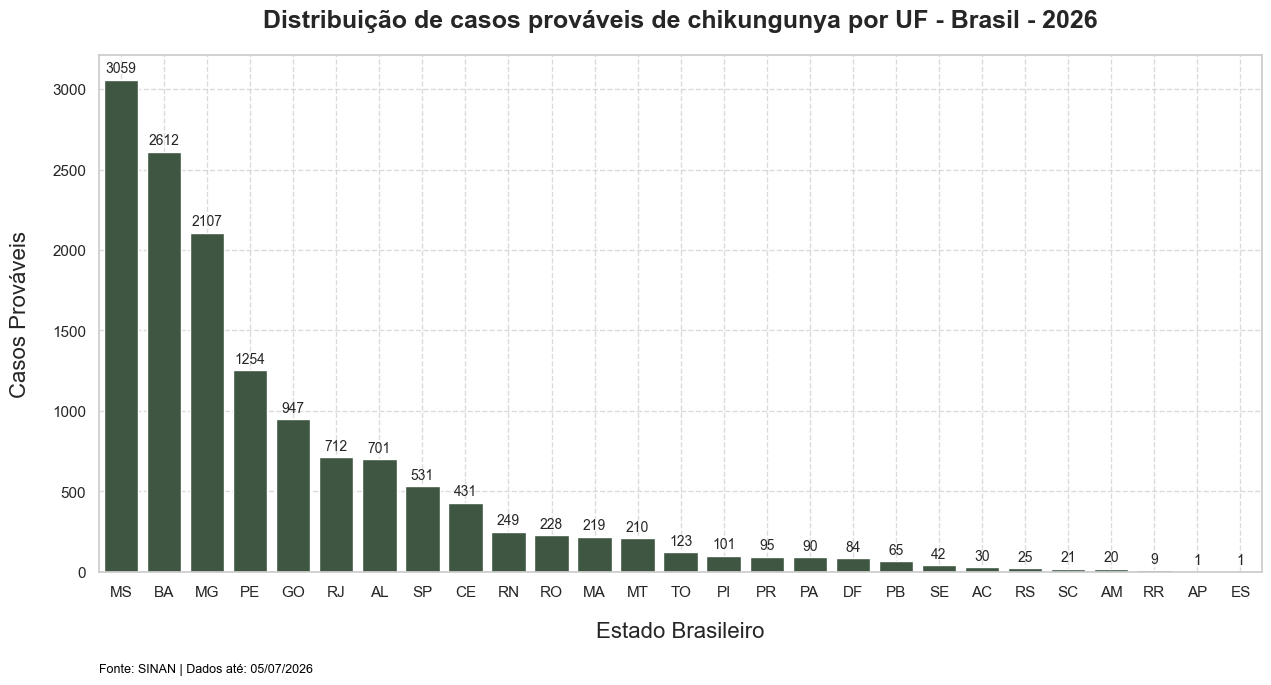

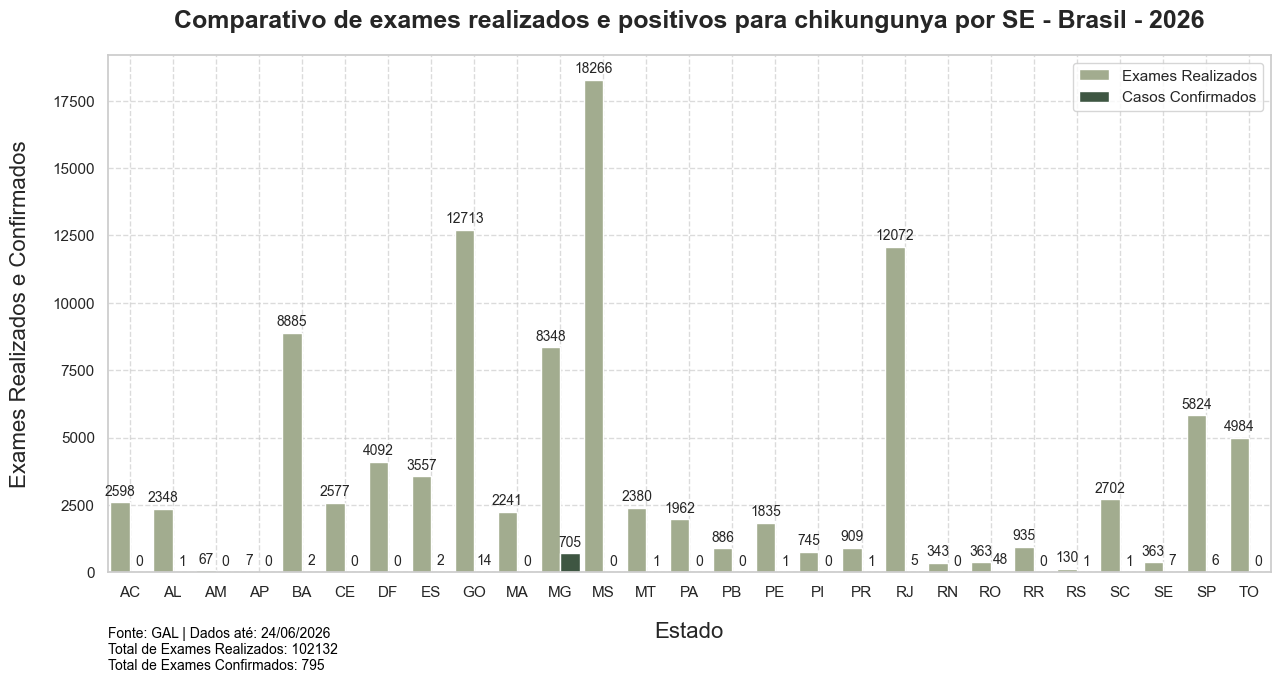

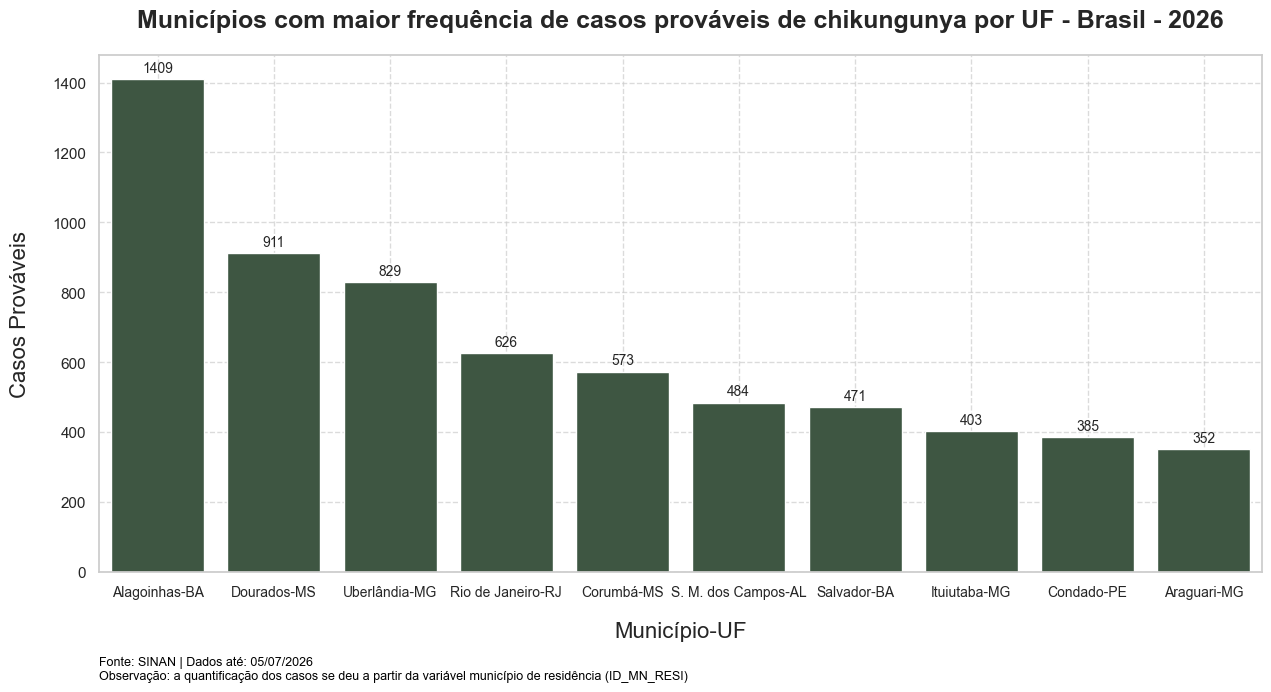

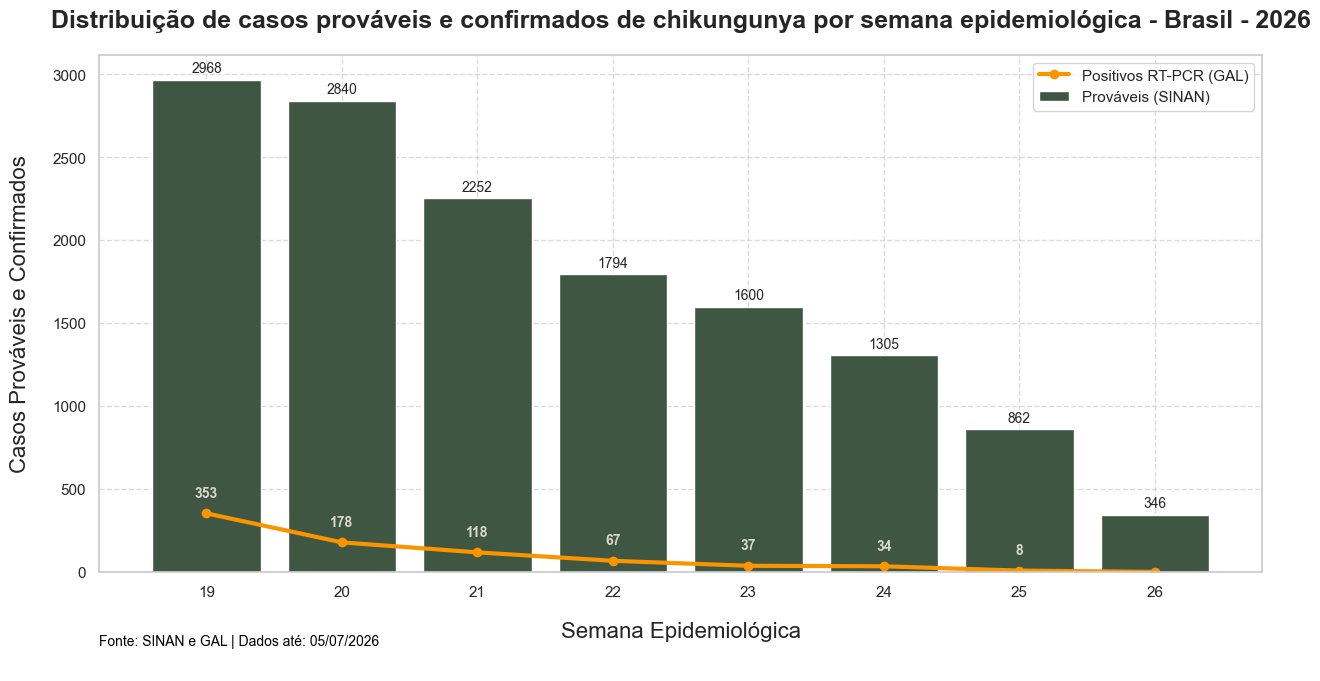

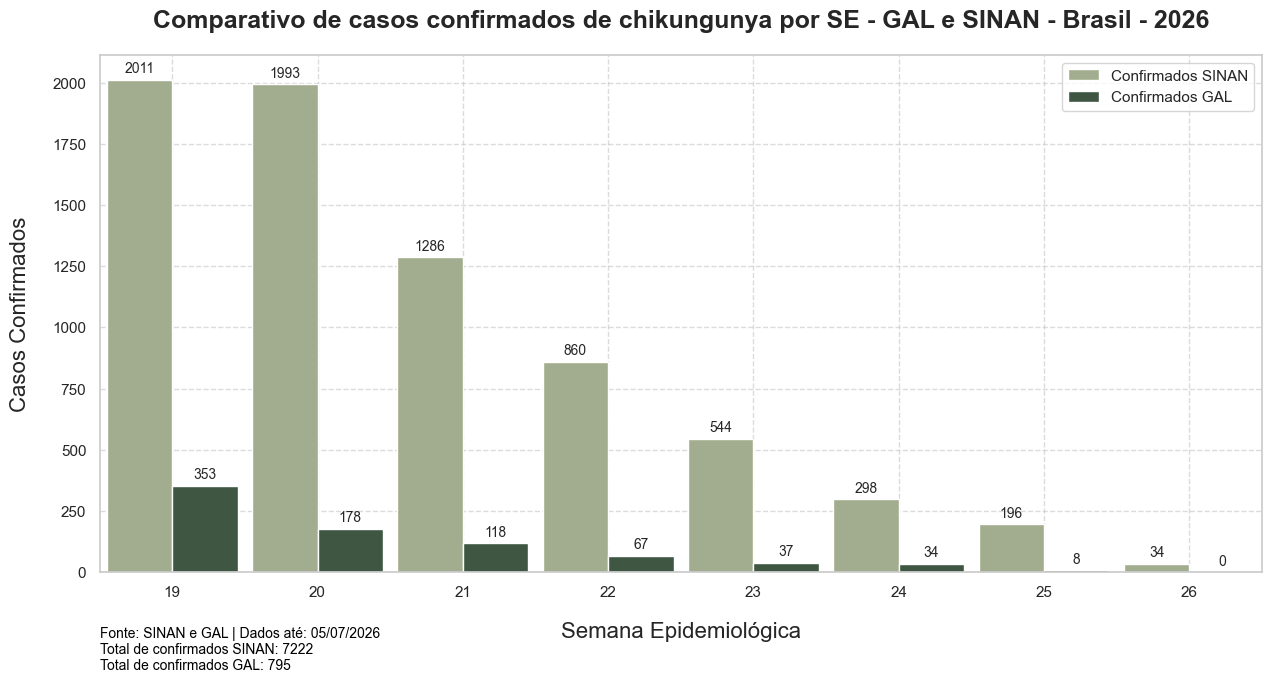

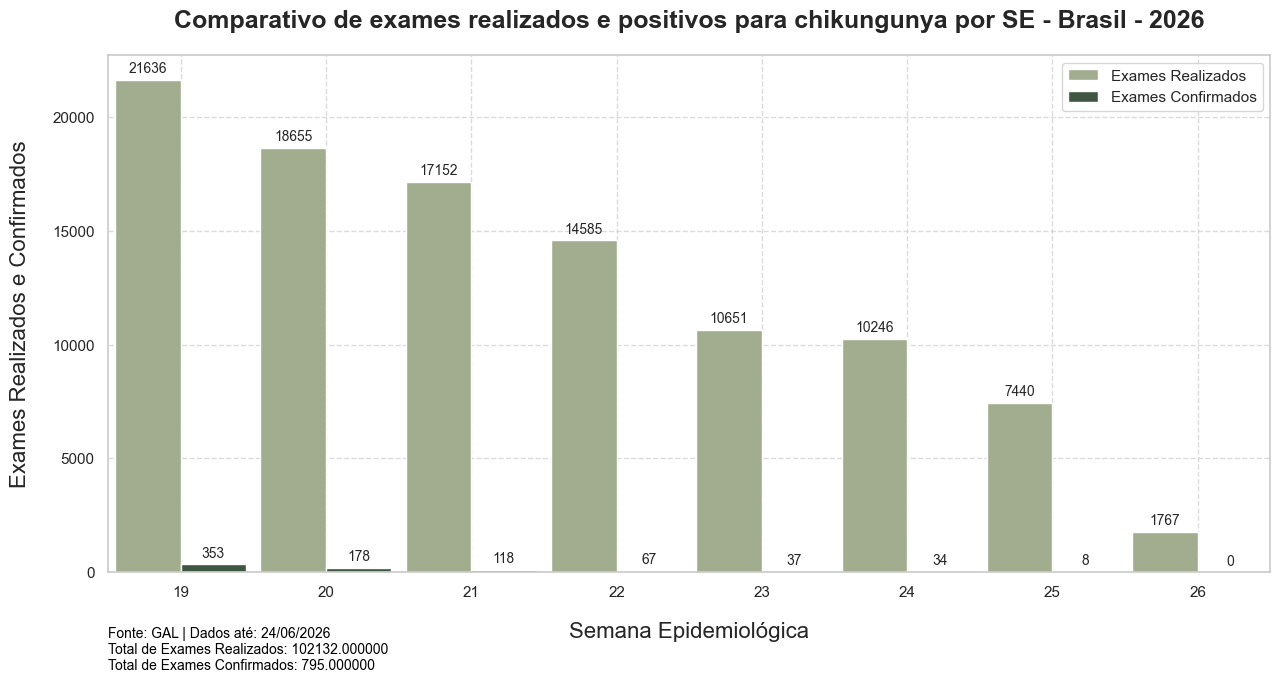

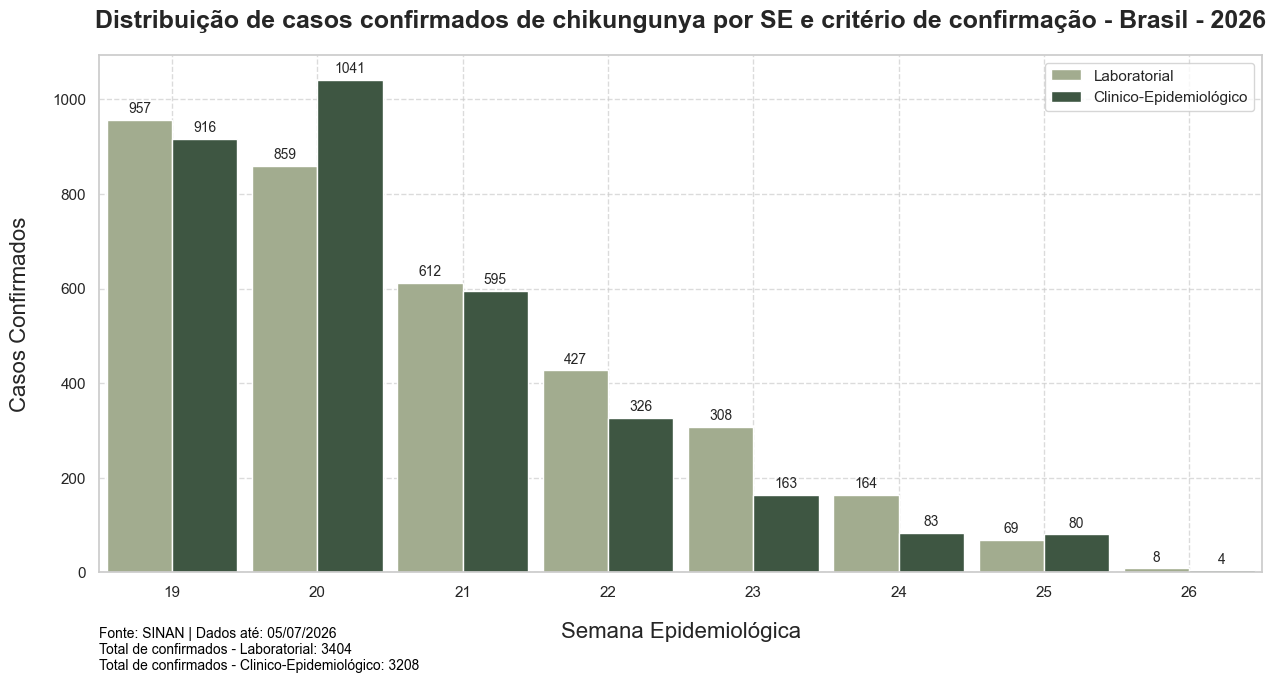

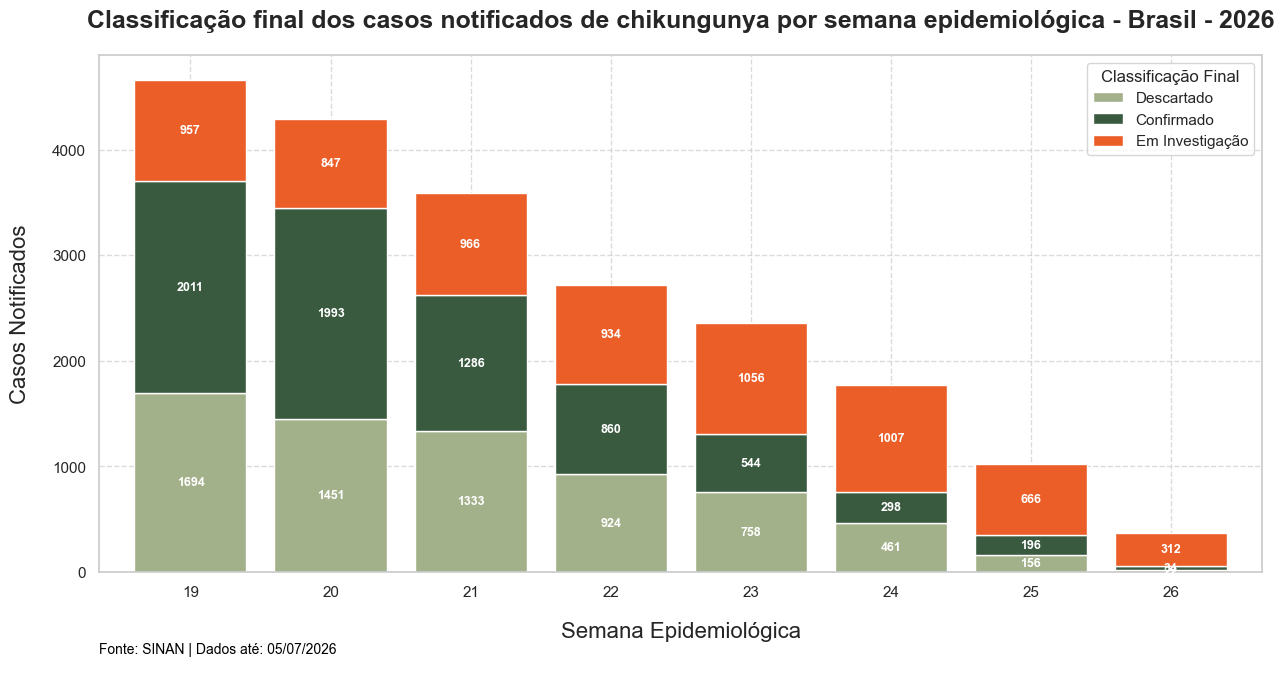

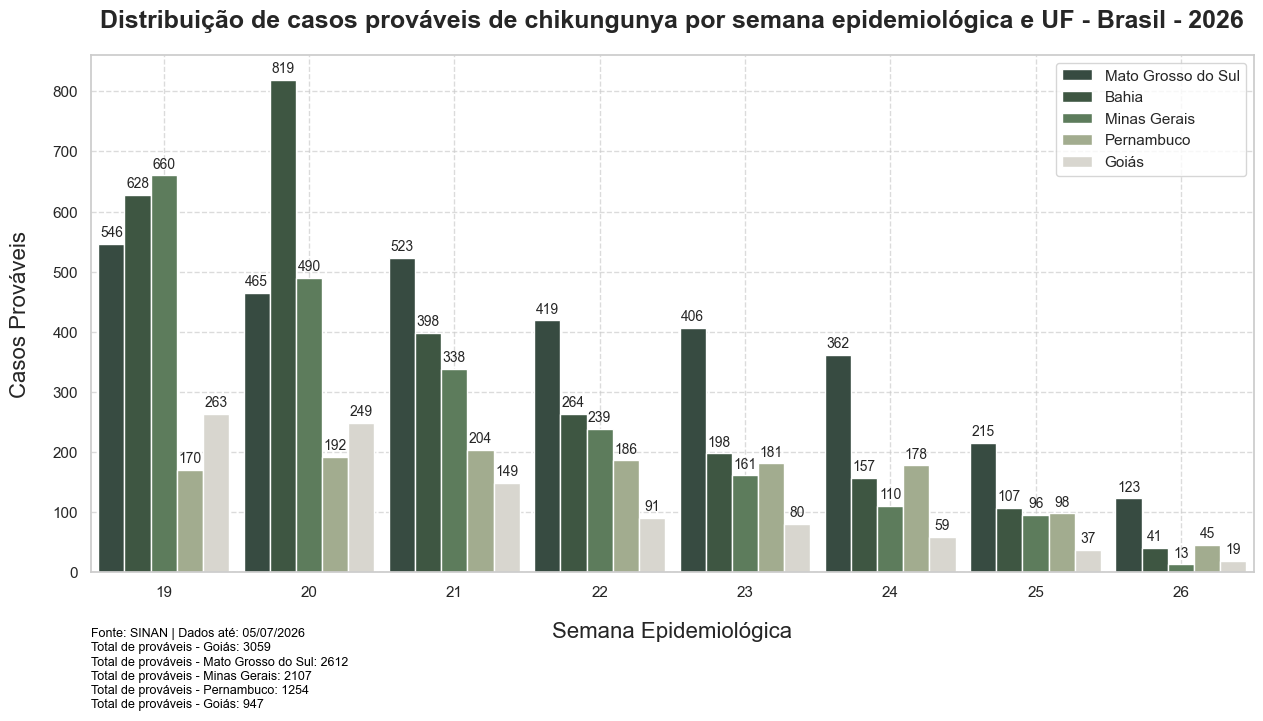

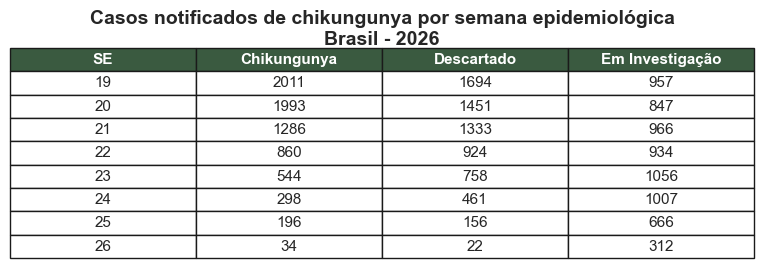

Arquivo Relatorio_Chikungunya_Brasil_2026.pdf gerado com sucesso!


In [ ]:
# MAPA COROPLÉTICO DOS CASOS PROVÁVEIS POR ESTADO
# Mapear os códigos para as siglas dos estados
df_estados = df_sinan['SG_UF'].map(mapa_uf).value_counts().reset_index()
df_estados.columns = ['Estado', 'Total']

# Desabilitar a verificação de SSL (caso tenha tido aquele problema)
ssl._create_default_https_context = ssl._create_unverified_context

# Carregar o mapa e cruzar os dados (Igual ao que você já tinha)
# O código fica muito mais rápido porque não depende da internet!
mapa_brasil = gpd.read_file('brazil-states.geojson')
mapa_brasil = mapa_brasil.rename(columns={'sigla': 'Estado'})

mapa_casos = mapa_brasil.merge(df_estados, on='Estado', how='left') # Descomente se for rodar
mapa_casos['Total'] = mapa_casos['Total'].fillna(0) 

# CRIAR AS FAIXAS DE CORES
cortes = [-1, 0, 100, 500, 2000, 5000, float('inf')]

# Definir os textos que vão aparecer na legenda para cada faixa
rotulos = [
    'Sem casos', 
    '1 a 100 casos', 
    '101 a 500 casos', 
    '501 a 2000 casos', 
    '2001 a 5000 casos',
    '>5000 casos'
]

# Criar a coluna 'Categoria' dizendo em qual faixa cada estado se encaixa
mapa_casos['Categoria'] = pd.cut(mapa_casos['Total'], bins=cortes, labels=rotulos)

# Dicionário escolhendo a cor exata para cada texto da legenda
dicionario_cores = {
    'Sem casos': '#e9f5db',        
    '1 a 100 casos': '#cfe1b9',    
    '101 a 500 casos': '#b5c99a',  
    '501 a 2000 casos': '#97a97c',  
    '2001 a 5000 casos': '#87986a', 
    '>5000 casos': '#414833'       
}

# Criar uma coluna aplicando a cor correspondente à categoria do estado
mapa_casos['Cor_Estado'] = mapa_casos['Categoria'].map(dicionario_cores)

# PLOTAR O MAPA
fig, ax = plt.subplots(figsize=(12, 12))

# Desenhar o mapa dizendo para usar exatamente a cor que colocamos na nova coluna
mapa_casos.plot(
    color=mapa_casos['Cor_Estado'], 
    linewidth=0.8, 
    edgecolor='0.3', # Linha cinza escura separando os estados
    ax=ax
)

# 5. CRIAR A LEGENDA CUSTOMIZADA
# Criamos "quadradinhos" (Patches) de cor para a legenda usando o nosso dicionário
lista_legendas = []
for rotulo in rotulos:
    quadradinho = mpatches.Patch(color=dicionario_cores[rotulo], label=rotulo)
    lista_legendas.append(quadradinho)

# Adicionar a legenda no mapa
ax.legend(
    handles=lista_legendas, 
    title='Casos Prováveis', 
    title_fontsize=14, 
    fontsize=12, 
    loc='lower right',
    bbox_to_anchor=(0.35, 0.17), # X (largura), Y (altura)
    frameon=True,
    shadow=False
)

# Estilização Final
ax.set_title('Distribuição Espacial de Casos Prováveis de Chikungunya por UF\nBrasil - 2026 - SE19 a SE26', 
             fontsize=18, fontweight='bold', pad=8)
ax.axis('off')
ax.text(
    0.13, 0.16,
    f'Fonte: SINAN\nDados até: {data_analise}',
    fontsize=10,
    color='black',
    transform=ax.transAxes,
    ha='left',
    va='top'
)

salvar_pasta = os.path.join(local_pasta, 'chik_brasil_provaveis_mapa_uf.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# GRÁFICO DE CASOS PROVÁVEIS POR UNIDADE FEDERATIVA
# Transformar o código da coluna UF em números
df_sinan['SG_UF'] = pd.to_numeric(df_sinan['SG_UF'], errors='coerce')

# Mapear os códigos para as siglas dos estados
df_estados = df_sinan['SG_UF'].map(mapa_uf).value_counts().reset_index()
df_estados.columns = ['Estado', 'Total']

# Configurar o estilo visual
grafico_estados = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_estados.add_subplot(gs[0])

# Criar o Gráfico de Barras Verticais
# Ordenado do maior para o menor automaticamente pelo value_counts()
sns.barplot(data=df_estados, x = 'Estado', y = 'Total', color= "#3a5a40", ax=ax)
ax.bar_label(ax.containers[0], fmt = '%d', padding = 3, fontsize = 10)
ax.set_title('Distribuição de casos prováveis de chikungunya por UF - Brasil - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Estado Brasileiro', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Prováveis', fontsize=16, labelpad=16)
#ax.set_ylim (0, 16000)
ax.grid(axis='y', linestyle = '--', alpha = 0.7)
ax.grid(axis='x', linestyle = '--', alpha = 0.7)

# Informações rodapé 
ax_rodape = grafico_estados.add_subplot(gs[1])
ax_rodape.axis('OFF')
rodape_texto = f'Fonte: SINAN | Dados até: {data_analise}'
ax_rodape.text(0.0, 0.05, rodape_texto, ha = 'left', va = 'center', fontsize = 9, color = 'black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_provaveis_uf.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches = 'tight')
plt.show()

# ======================================================== #

# GRÁFICO DE EXAMES REALIZADOS E CONFIRMADOS (GAL) POR UF
df_gal_final['UF_COD'] = pd.to_numeric(df_gal_final['UF_COD'], errors='coerce')

# Mapear as siglas dos estados e as siglas dos estados
df_gal_final['UF_BR'] = df_gal_final['UF_COD'].map(mapa_uf)
df_uf_gal = df_gal_final.groupby('UF_BR')[['Exames_Realizados', 'Casos_Positivos']].sum().reset_index()
df_uf_gal.columns = ['UF_BR', 'Realizados', 'Positivos']

# contar exames realizados na base do GAL
df_exames = df_uf_gal[['UF_BR', 'Realizados']].copy()
df_exames.columns = ['UF_BR', 'Total']

# Contar os casos positivos na base do GAL
df_confirmados = df_uf_gal[['UF_BR', 'Positivos']].copy()
df_confirmados.columns = ['UF_BR', 'Total']

df_exames['Exames'] = 'Exames Realizados'
df_confirmados['Exames'] = 'Casos Confirmados'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_gal_combinado = pd.concat([df_exames, df_confirmados], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_gal_combinado, x='UF_BR', y='Total', hue='Exames',
            palette= ['#a3b18a', '#3a5a40'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title('Comparativo de exames realizados e positivos para chikungunya por SE - Brasil - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Estado', fontsize=16, labelpad=16)
ax.set_ylabel('Exames Realizados e Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: GAL | Dados até: 24/06/2026\n'
                f'Total de Exames Realizados: {df_exames['Total'].sum():.0f}\n'
                f'Total de Exames Confirmados: {df_confirmados['Total'].sum():.0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_realizados_confirmados_gal_uf.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# MUNICÍPIOS COM MAIOR FREQUÊNCIA DE CASOS PROVÁVEIS
# Tratamento dos códigos IBGE para o cruzamento
# Transformar o código IBGE de 7 dígitos do arquivo em 6 dígitos (como no SINAN)
df_municipios['COD_IBGE_6'] = df_municipios['CÓDIGO DO MUNICÍPIO - IBGE'].astype(str).str[:6]

# Garantir que a coluna do SINAN também seja tratada como texto (string)
# IMPORTANTE: Substitua 'ID_MUNICIP' pelo nome exato da coluna de município na sua base do SINAN
df_sinan['ID_MN_RESI'] = df_sinan['ID_MN_RESI'].astype(str)

# Cruzar (Merge) as duas bases
# Trazemos as informações do df_municipios para o df_sinan baseando-se no código de 6 dígitos
df_completo = pd.merge(df_sinan, df_municipios, left_on='ID_MN_RESI', right_on='COD_IBGE_6', how='left')

# Contar os casos por município
# Contamos a frequência de cada nome na coluna 'MUNICÍPIO - IBGE'
casos_por_municipio = df_completo['MUNICÍPIO - IBGE - UF'].value_counts().reset_index()
casos_por_municipio.columns = ['Município', 'Total']

# Selecionar os 10 municípios com mais casos para o gráfico não ficar ilegível
top_municipios = casos_por_municipio.head(10)

# Configurar o estilo visual
grafico_municipio = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_municipio.add_subplot(gs[0])

# Criar o Gráfico de Barras Verticais
# Ordenado do maior para o menor automaticamente pelo value_counts()
sns.barplot(data=top_municipios, x = 'Município', y = 'Total', color= "#3a5a40", ax=ax)
ax.bar_label(ax.containers[0], fmt = '%d', padding = 3, fontsize = 10)
ax.set_title('Municípios com maior frequência de casos prováveis de chikungunya por UF - Brasil - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Município-UF', fontsize=16, labelpad=16)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylabel('Casos Prováveis', fontsize=16, labelpad=16)
#ax.set_ylim (0, 10000)
ax.grid(axis='y', linestyle = '--', alpha = 0.7)
ax.grid(axis='x', linestyle = '--', alpha = 0.7)

# Informações rodapé 
ax_rodape = grafico_municipio.add_subplot(gs[1])
ax_rodape.axis('OFF')
rodape_texto = (f'Fonte: SINAN | Dados até: {data_analise}\n'
                f'Observação: a quantificação dos casos se deu a partir da variável município de residência (ID_MN_RESI)')
ax_rodape.text(0.0, 0.05, rodape_texto, ha = 'left', va = 'center', fontsize = 9, color = 'black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_provaveis_municipios.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches = 'tight')
plt.show()

# ======================================================== #

# CASOS PROVÁVEIS E CONFIRMADOS (GAL) POR SEMANA EPIDEMIOLÓGICA
# Carregamento e Tratamento dos Dados
df_semanas = df_sinan.groupby('SE').size().reset_index(name='Total')
df_gal_semana = df_gal_final.groupby('SE')[['Casos_Positivos']].sum().reset_index()

# União de dois dataframe 
# Isso garante que a barra e a linha fiquem perfeitamente alinhadas na mesma semana
df_merged = pd.merge(df_semanas, df_gal_semana, on='SE', how='left').fillna(0)

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

# Criar o Gráfico de Barras Verticais (Usando 'color' e 'label')
sns.barplot(data=df_merged, x='SE', y='Total', color="#3a5a40", ax=ax, label='Prováveis (SINAN)')

# Rótulos das Barras
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=10)

# Criar o Gráfico de Linha
# ax.plot é mais seguro para garantir o alinhamento central com as barras do seaborn
ax.plot(df_merged.index, df_merged['Casos_Positivos'], color="#fa9500", linewidth=3, marker='o', markersize=6, label='Positivos RT-PCR (GAL)')

# Rótulos da Linha (Loop que passa por cada ponto e escreve o número em cima)
for i, row in df_merged.iterrows():
    # Só coloca o rótulo se tiver mais de 0 casos para não poluir o gráfico
    if row['Casos_Positivos'] > 0: 
        # O +80 abaixo empurra o texto um pouco para cima do ponto da linha para não sobrepor
        ax.text(i, row['Casos_Positivos'] + 80, f"{int(row['Casos_Positivos'])}", 
                ha='center', va='bottom', fontsize=10, color="#dad7cd", fontweight='bold')

# Estilização do Eixo e Legenda
ax.set_title('Distribuição de casos prováveis e confirmados de chikungunya por semana epidemiológica - Brasil - 2026', 
            fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Prováveis e Confirmados', fontsize=16, labelpad=16)
#ax.set_ylim(0, 2700)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Agora a legenda vai funcionar perfeitamente pegando os 'labels' definidos nas barras e linhas
ax.legend(fontsize=11, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = f'Fonte: SINAN e GAL | Dados até: {data_analise}\n'
# Coloquei 0.5 no eixo Y para centralizar direitinho no rodapé
ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_provaveis_confirmados_semana.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# COMPARATIVO ENTRE CONFIRMADOS SINAN E CONFIRMADOS GAL
# Filtrar casos confirmados na base do SINAN
df_semanas = df_sinan[df_sinan['CLASSI_FIN'] == 13]['SE'].value_counts().reset_index()
df_semanas.columns = ['SE', 'Total']
df_semanas = df_semanas.sort_values('SE').reset_index(drop=True)

# Contar os casos positivos na base do GAL
df_conf = df_gal_final.groupby('SE')['Casos_Positivos'].sum().reset_index()
df_conf.columns = ['SE', 'Total']

df_semanas['Confirmados'] = 'Confirmados SINAN'
df_conf['Confirmados'] = 'Confirmados GAL'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_combinado = pd.concat([df_semanas, df_conf], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',
            palette= ['#a3b18a', '#3a5a40'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title('Comparativo de casos confirmados de chikungunya por SE - GAL e SINAN - Brasil - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: SINAN e GAL | Dados até: {data_analise}\n'
                f'Total de confirmados SINAN: {df_semanas['Total'].sum():.0f}\n'
                f'Total de confirmados GAL: {df_conf['Total'].sum():.0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_confirmados_sinan_gal.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# COMPARATIVO ENTRE EXAMES REALIZADOS E CONFIRMADOS GAL POR SEMANA EPIDEMIOLÓGICA

# contar exames realizados na base do GAL
df_exames = df_gal_final.groupby('SE')['Exames_Realizados'].sum().reset_index()
df_exames.columns = ['SE', 'Total']

# Contar os casos positivos na base do GAL
df_conf = df_gal_final.groupby('SE')['Casos_Positivos'].sum().reset_index()
df_conf.columns = ['SE', 'Total']

df_exames['Exames'] = 'Exames Realizados'
df_conf['Exames'] = 'Exames Confirmados'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_gal_combinado = pd.concat([df_exames, df_conf], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_gal_combinado, x='SE', y='Total', hue='Exames',
            palette= ['#a3b18a', '#3a5a40'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title('Comparativo de exames realizados e positivos para chikungunya por SE - Brasil - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Exames Realizados e Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: GAL | Dados até: 24/06/2026\n'
                f'Total de Exames Realizados: {df_exames['Total'].sum():0f}\n'
                f'Total de Exames Confirmados: {df_conf['Total'].sum():0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_realizados_confirmados_gal_semana.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# CASOS CONFIRMADOS POR CRITÉRIO DE CONFIRMAÇÃO APLICADO
# Filtrar casos conformados por critério laboratorial na base do SINAN
df_conf_lab = df_sinan[(df_sinan['CLASSI_FIN'] == 13) & (df_sinan['CRITERIO'] == 1)]['SE'].value_counts().reset_index()
df_conf_lab.columns = ['SE', 'Total']
df_conf_lab = df_conf_lab.sort_values('SE').reset_index(drop=True)

# Filtrar casos confirmados por criterio clini-epidemiologico na base do SINAN
df_conf_clep = df_sinan[(df_sinan['CLASSI_FIN'] == 13) & (df_sinan['CRITERIO'] == 2)]['SE'].value_counts().reset_index()
df_conf_clep.columns = ['SE', 'Total']
df_conf_clep = df_conf_clep.sort_values('SE').reset_index(drop=True)

df_conf_lab['Confirmados'] = 'Laboratorial'
df_conf_clep['Confirmados'] = 'Clinico-Epidemiológico'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_combinado = pd.concat([df_conf_lab, df_conf_clep], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',
            palette= ['#a3b18a', '#3a5a40'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title('Distribuição de casos confirmados de chikungunya por SE e critério de confirmação - Brasil - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: SINAN | Dados até: {data_analise}\n'
                f'Total de confirmados - Laboratorial: {df_conf_lab['Total'].sum():.0f}\n'
                f'Total de confirmados - Clinico-Epidemiológico: {df_conf_clep['Total'].sum():.0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_confirmados_criterio.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# CLASSIFICAÇÃO FINAL POR SEMANA EPIDEMIOLÓGICA
df_notif = pd.read_excel('chik_brasil_notificados_2026.xlsx')

# Tratamento da Classificação
# Transformar em número. O que for vazio ('') vira NaN (Nulo)
df_notif['CLASSI_FIN'] = pd.to_numeric(df_notif['CLASSI_FIN'], errors='coerce')

# Preencher os valores nulos (NaN) com um código numérico fictício (ex: 99) 
# Isso impede que o groupby ignore os casos "Em Investigação"
df_notif['CLASSI_FIN'] = df_notif['CLASSI_FIN'].fillna(99)

# Novo dicionário com o código 99 representando o que estava vazio
mapa_class = {5: 'Descartado', 13: 'Confirmado', 99: 'Em Investigação'}

# Agrupar os dados
# Dataframe para o gráfico de barras empilhadas e tabela
df_class = df_notif.groupby(['SE', 'CLASSI_FIN']).size().unstack(fill_value=0) 
df_class = df_class.rename(columns=mapa_class)

# Configurar o estilo visual
grafico_class = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_class.add_subplot(gs[0])

# Criar o Gráfico de Barras Empilhadas
# Adicionei cores distintas para cada classificação
cores = {'Confirmado': '#3a5a40', 'Descartado': '#a3b18a', 'Em Investigação': '#eb5e28'}
df_class.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=[cores.get(col, '#333333') for col in df_class.columns])

# Adicionar os rótulos de dados (bar_label)
# Como são barras empilhadas, precisamos passar por CADA container (cada pedaço da barra)
for c in ax.containers:
    # Condição para só escrever o número se ele for maior que 0 (evita poluir o gráfico com zeros)
    labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in c]
    # label_type='center' coloca o número bem no meio da cor respectiva
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('Classificação final dos casos notificados de chikungunya por semana epidemiológica - Brasil - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Notificados', fontsize=16, labelpad=16)

# O eixo X no pandas fica rotacionado em 90 graus por padrão. Isso conserta e deixa reto:
plt.xticks(rotation=0) 

# Ajustar o limite do eixo Y (adapte se necessário)
# ax.set_ylim(0, 1400) # Removi temporariamente para o pandas ajustar automaticamente às barras somadas

# Melhorar a legenda
ax.legend(title='Classificação Final', fontsize=11, title_fontsize=12, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7) # Tirar as linhas verticais para ficar mais limpo

# Informações rodapé 
ax_rodape = grafico_class.add_subplot(gs[1])
ax_rodape.axis('off') # Minúsculo
rodape_texto = f'Fonte: SINAN | Dados até: {data_analise}'
# Ajustado para ficar centralizado verticalmente no rodapé
ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_provaveis_classificacao.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# DISTRIBUIÇÃO DE CASOS PROVÁVEIS ENTRE OS ESTADOS COM MAIS CASOS
# Carregar a base de dados
df_grafico = pd.read_excel('chik_brasil_provaveis_2026.xlsx')

# Transformar o código da coluna SE em números
df_grafico['SE'] = pd.to_numeric(df_grafico['SE'], errors='coerce')

# Criação dos dataframe estaduais (Filtrar pelo código do estado)
df_uf1 = df_grafico[df_grafico['SG_UF'] == 50]['SE'].value_counts().reset_index(name='Total').rename(columns={'index': 'SE'})
df_uf1 = df_uf1.sort_values('SE').reset_index(drop=True)

df_uf2 = df_grafico[df_grafico['SG_UF'] == 29]['SE'].value_counts().reset_index(name='Total').rename(columns={'index': 'SE'})
df_uf2 = df_uf2.sort_values('SE').reset_index(drop=True)

df_uf3 = df_grafico[df_grafico['SG_UF'] == 31]['SE'].value_counts().reset_index(name='Total').rename(columns={'index': 'SE'})
df_uf3 = df_uf3.sort_values('SE').reset_index(drop=True)

df_uf4 = df_grafico[df_grafico['SG_UF'] == 26]['SE'].value_counts().reset_index(name='Total').rename(columns={'index': 'SE'})
df_uf4 = df_uf4.sort_values('SE').reset_index(drop=True)

df_uf5 = df_grafico[df_grafico['SG_UF'] == 52]['SE'].value_counts().reset_index(name='Total').rename(columns={'index': 'SE'})
df_uf5 = df_uf5.sort_values('SE').reset_index(drop=True)

# Criação da coluna estado nos dataframe
df_uf1['Estado'] = 'Mato Grosso do Sul'
df_uf2['Estado'] = 'Bahia'
df_uf3['Estado'] = 'Minas Gerais'
df_uf4['Estado'] = 'Pernambuco'
df_uf5['Estado'] = 'Goiás'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

# Criar o Gráfico de Barras Verticais
df_combinado = pd.concat([df_uf1, df_uf2, df_uf3, df_uf4, df_uf5])

sns.barplot(data = df_combinado, x= 'SE', y= 'Total', hue= 'Estado', 
            palette= ['#344e41', '#3a5a40', '#588157', '#a3b18a', '#dad7cd' ], ax=ax, width = 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding= 3, fontsize = 10)

ax.set_title('Distribuição de casos prováveis de chikungunya por semana epidemiológica e UF - Brasil - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Prováveis', fontsize=16, labelpad=16)
#ax.set_ylim (0, 1400)
ax.grid(axis='y', linestyle = '--', alpha = 0.7)
ax.grid(axis='x', linestyle = '--', alpha = 0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('OFF')
rodape_texto = (f'Fonte: SINAN | Dados até: {data_analise}\n'
                f'Total de prováveis - Goiás: {df_uf1['Total'].sum():.0f}\n'
                f'Total de prováveis - Mato Grosso do Sul: {df_uf2['Total'].sum():.0f}\n'
                f'Total de prováveis - Minas Gerais: {df_uf3['Total'].sum():.0f}\n'
                f'Total de prováveis - Pernambuco: {df_uf4['Total'].sum():.0f}\n'
                f'Total de prováveis - Goiás: {df_uf5['Total'].sum():.0f}')
ax_rodape.text(0.0, 0.05, rodape_texto, ha = 'left', va = 'center', fontsize = 9, color = 'black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_comparacao_estados.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches = 'tight')
plt.show()

# ======================================================== #

# TABELA DE CASOS NOTIFICADOS POR SEMANA EPIDEMIOLÓGICA E CLASSIFICAÇÃO FINAL
# 2. Tratar os dados e mapear classificações
df_notif['SE'] = pd.to_numeric(df_notif['SE'], errors='coerce')

mapa_class = {5: 'Descartado', 13: 'Chikungunya'}
df_notif['CLASSI_FIN'] = df_notif['CLASSI_FIN'].map(mapa_class).fillna('Em Investigação')

# 3. Agrupar os dados e resetar o índice para que 'SE' vire uma coluna comum
df_class = df_notif.groupby(['SE', 'CLASSI_FIN']).size().unstack(fill_value=0)
df_class = df_class.reset_index() # Garante que a Semana Epidemiológica (SE) apareça na tabela

# 4. Criar a figura com Matplotlib
# Dica: aumente o tamanho (figsize) se você tiver muitas Semanas Epidemiológicas (linhas)
# fig, ax = plt.subplots(figsize=(8, len(df_class) * 0.4 + 1))
fig, ax = plt.subplots(figsize=(8, len(df_class) * 0.3)) 

ax.axis('tight')
ax.axis('off')

# 5. Adicionar a tabela à figura
tabela_fig = ax.table(
    cellText=df_class.values, 
    colLabels=df_class.columns, 
    cellLoc='center', 
    loc='center'
)

# 6. Estilização da tabela (Opcional - Melhora o visual do relatório)
tabela_fig.auto_set_font_size(False)
tabela_fig.set_fontsize(11)
tabela_fig.scale(1.2, 1.4)

plt.title(
    'Casos notificados de chikungunya por semana epidemiológica\nBrasil - 2026', 
    fontsize=14, 
    weight='bold', 
    pad=5,          # Adiciona espaçamento interno
    y=1.05           # Move o título ligeiramente para cima (evita sobreposição)
)

# Destacar o cabeçalho com uma cor (ex: cinza claro)
for (row, col), cell in tabela_fig.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#3a5a40') # Azul profissional para o cabeçalho

# 7. Salvar e exibir a imagem
salvar_pasta = os.path.join(local_pasta, 'chik_brasil_tabela_notificados.png')
plt.savefig(salvar_pasta, bbox_inches='tight', dpi=300)
plt.show()

# ======================================================== #

# SALVAR GRÁFICOS EM PDF ÚNICO
def gerar_pdf_dashboard(lista_arquivos, nome_pdf='Relatorio_Chikungunya_Brasil_2026.pdf'):
    c = canvas.Canvas(nome_pdf, pagesize=A4)
    largura, altura = A4
    margem = 30
    
    # Função auxiliar para desenhar o cabeçalho em todas as páginas
    def desenhar_cabecalho(canvas):
        canvas.setFont("Helvetica-Bold", 16)
        canvas.drawCentredString(largura / 2, altura - 25, "Análise Chikungunya - Brasil - 2026")
        canvas.line(margem, altura - 35, largura - margem, altura - 35) # Linha divisória

    def processar_paginas(imagens_lista):
        # Definimos um espaçamento interno entre as imagens
        espacamento = 5 
        area_h = (altura / 2) - (margem + 40) 
        largura_max = largura - (2 * margem)
    
        def desenhar_figura(img_path, pos_y):
            # Verifica se a imagem existe antes de desenhar (evita o erro OSError)
            if os.path.exists(img_path):
                c.drawImage(img_path, margem, pos_y, width=largura_max, height=area_h, preserveAspectRatio=True)
            else:
                print(f"⚠️ Aviso: A imagem {img_path} não foi encontrada.")
        
        def desenhar_rodape(canvas, texto):
            canvas.setFont("Helvetica-Oblique", 5) 
    
            # 1. Obtém as dimensões atuais da página do canvas (largura e altura)
            largura_pagina, altura_pagina = canvas._pagesize
    
            # 2. Calcula o ponto central do eixo X
            centro_x = largura_pagina / 2.0
    
            # 3. Usa o método específico para desenhar texto centralizado
            # O eixo Y continua sendo 20 (próximo à borda inferior)
            canvas.drawCentredString(centro_x, 20, texto)

        texto_rodape = 'Análise realizada por Coordenação-Geral de Vigilância das Arboviroses (CGARB/DEDT/SVSA/MS)'

        # 1. PÁGINA 1
        desenhar_cabecalho(c)
        # Ajustei o Y para dar uma margem extra em relação ao cabeçalho e ao centro
        desenhar_figura(imagens_lista[0], (altura / 2) + espacamento) 
        desenhar_figura(imagens_lista[1], margem)
        c.showPage()
    
        # 2. PÁGINAS SEGUINTES
        restante = imagens_lista[2:]
        for i in range(0, len(restante), 2):
            desenhar_cabecalho(c)
            grupo = restante[i:i+2]
        
            pos_y_lista = [(altura / 2) + espacamento, margem]
        
            for idx, img_path in enumerate(grupo):
                desenhar_figura(img_path, pos_y_lista[idx])
            
            desenhar_rodape(c, texto_rodape)
            c.showPage()

    processar_paginas(lista_arquivos)
    c.save()
    print(f"Arquivo {os.path.basename(nome_pdf)} gerado com sucesso!")

# Lista dos arquivos
arquivos = [
    'chik_brasil_provaveis_mapa_uf.png',
    'chik_brasil_provaveis_uf.png',
    'chik_brasil_comparacao_estados.png',
    'chik_brasil_provaveis_municipios.png',
    'chik_brasil_provaveis_confirmados_semana.png',
    'chik_brasil_confirmados_sinan_gal.png',
    'chik_brasil_realizados_confirmados_gal_uf.png',
    'chik_brasil_realizados_confirmados_gal_semana.png',
    'chik_brasil_confirmados_criterio.png',
    'chik_brasil_provaveis_classificacao.png',
    'chik_brasil_tabela_notificados.png'
]

graficos = [os.path.join(local_pasta, nome) for nome in arquivos]
salvar_pdf = os.path.join(local_pasta, f'Relatorio_Chikungunya_Brasil_2026.pdf')

gerar_pdf_dashboard(graficos, nome_pdf=salvar_pdf)

#### ANÁLISE ESTADO

A pasta Chikungunya_Goiás_graficos já existe. Os arquivos serão salvos nela.


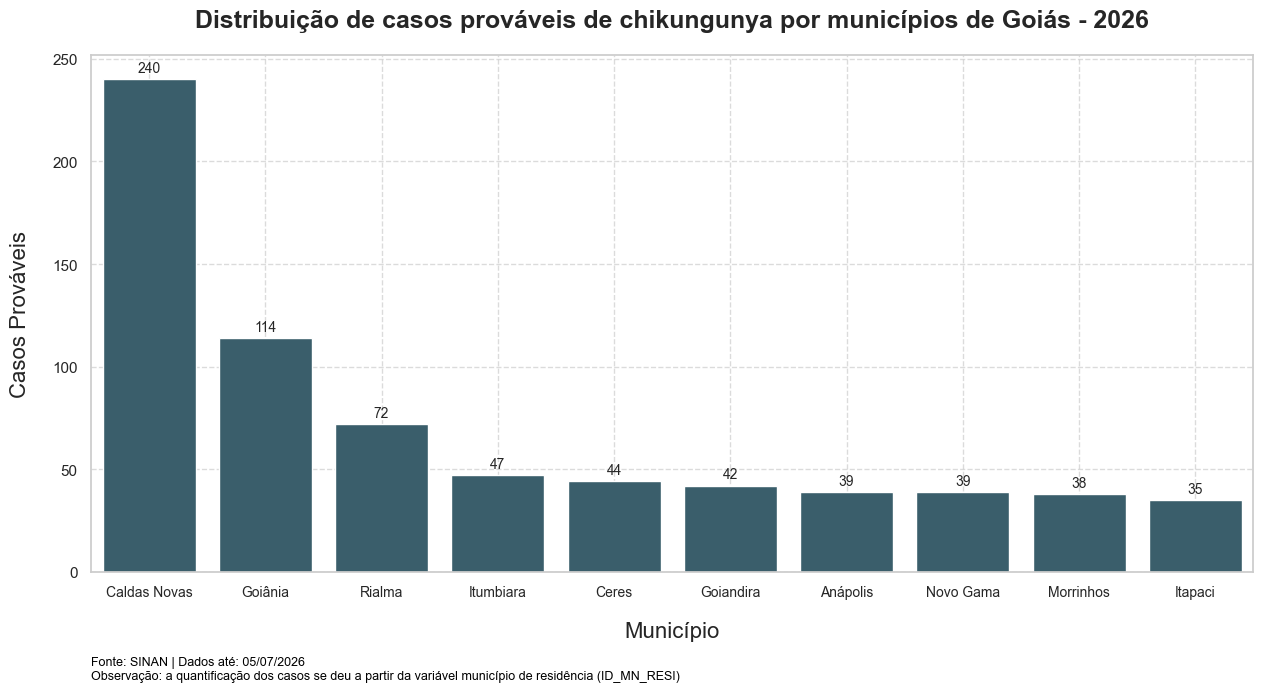

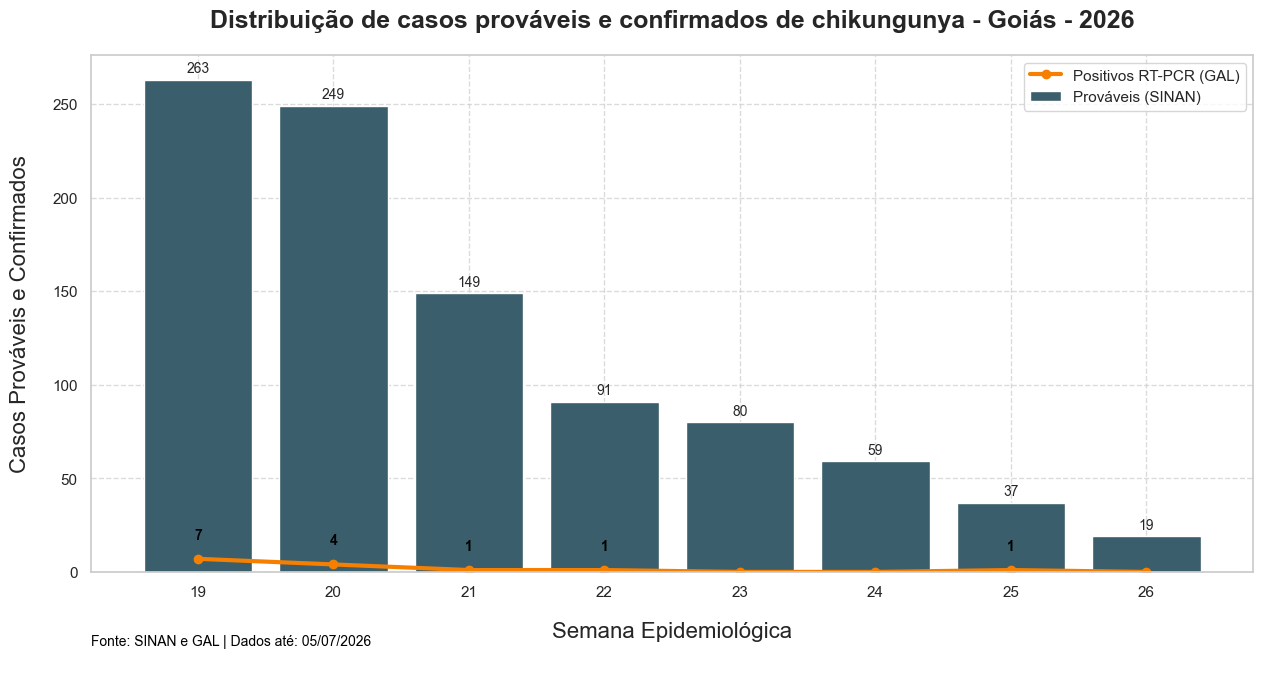

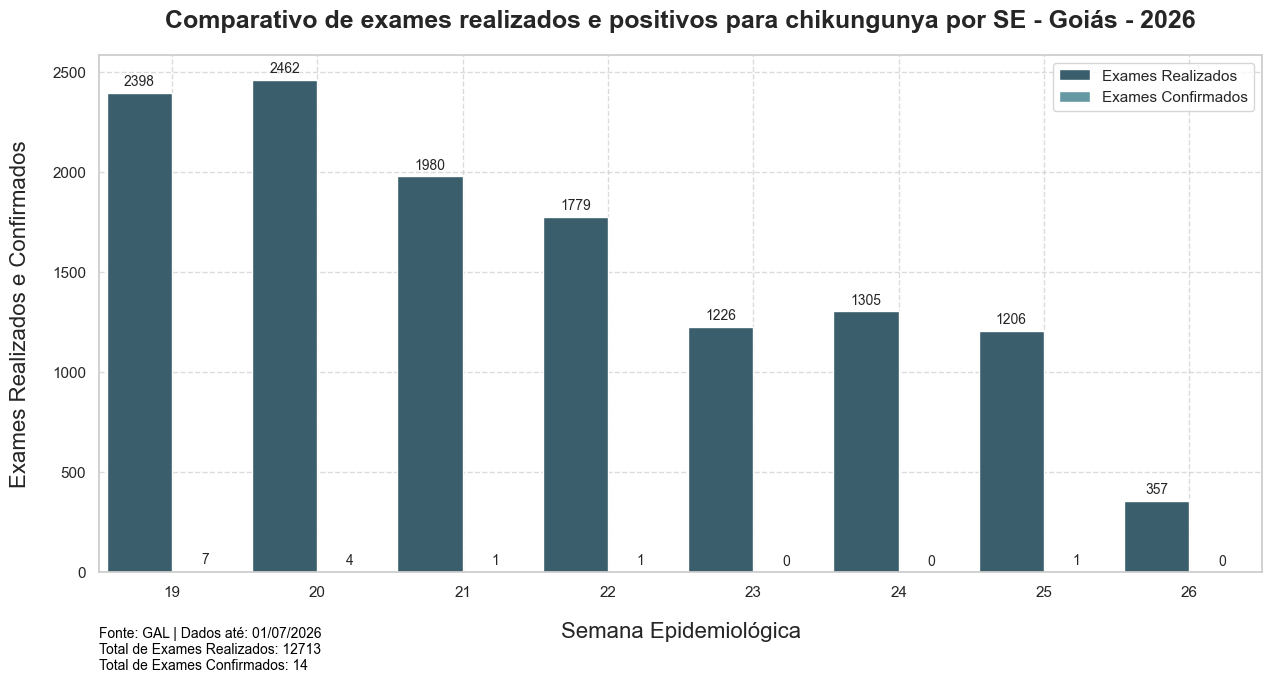

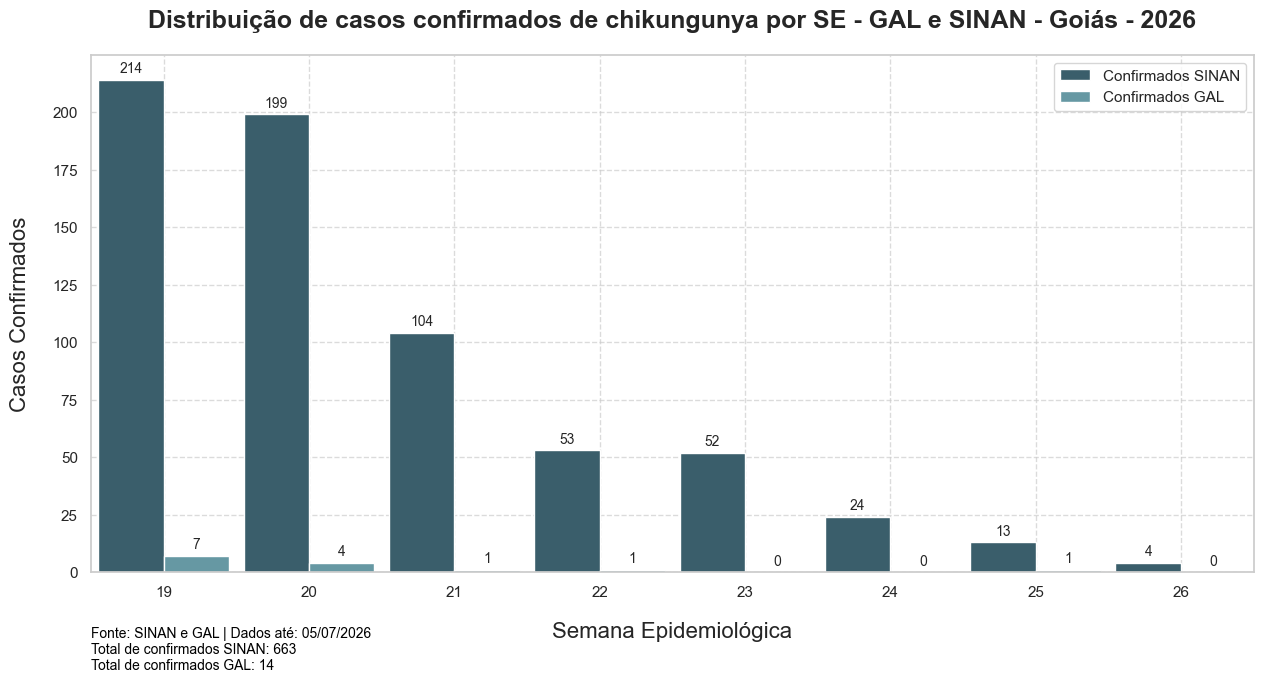

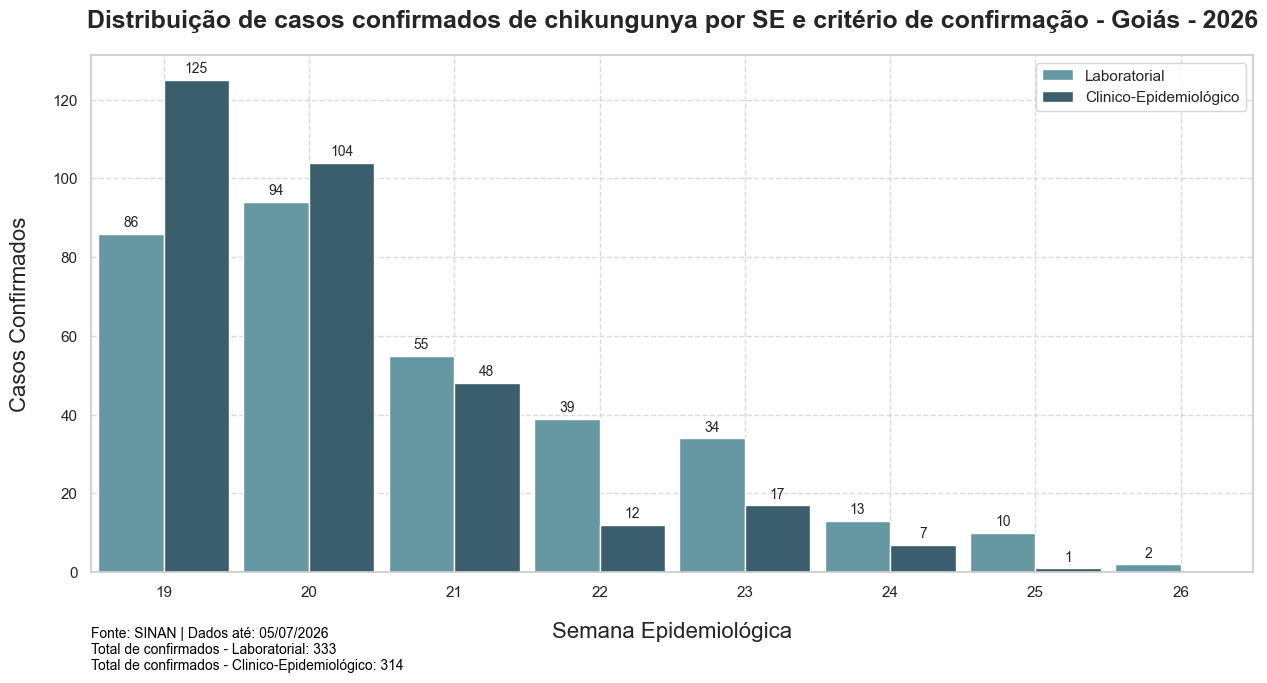

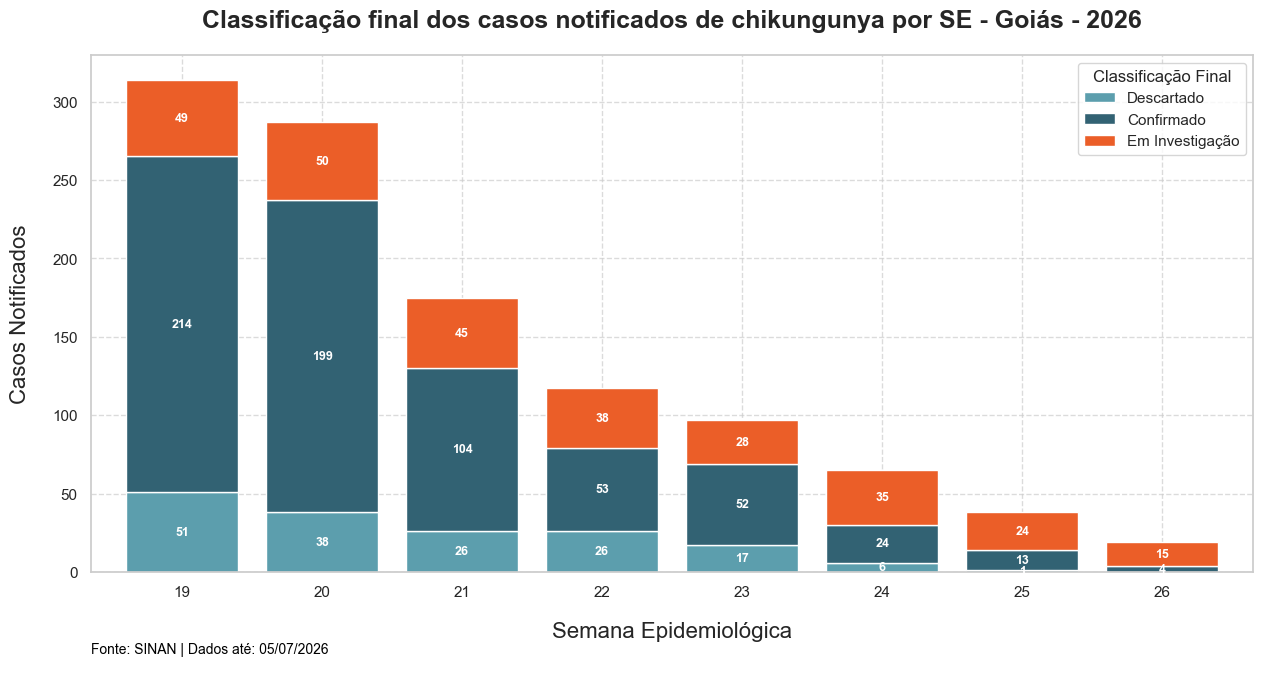

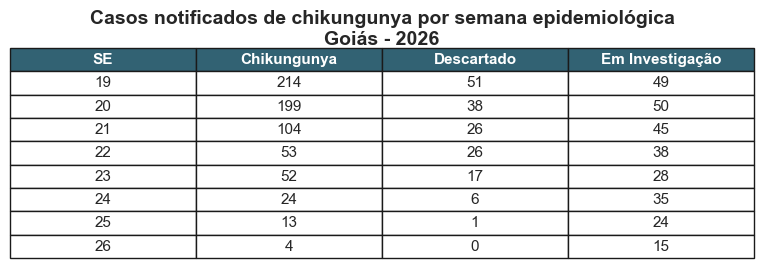

Arquivo Relatorio_Chikungunya_Goiás_2026.pdf gerado com sucesso!


In [33]:
# FILTROS PARA DELIMITAR ANÁLISE
nome_estado = 'Goiás'
filtro_estado = 52
data_analise = '05/07/2026'

# ======================================================== #

# Criar pasta para salvar os arquivos
nome_pasta = f'Chikungunya_{nome_estado}_graficos'
local_salvar = os.getcwd()
local_pasta = os.path.join(local_salvar, nome_pasta)

if not os.path.exists(local_pasta):
    os.makedirs(local_pasta)
    print(f"Pasta {nome_pasta} criada!")
else:
    print(f"A pasta {nome_pasta} já existe. Os arquivos serão salvos nela.")

# ======================================================== #

# Carregamento das bases de dados
df_sinan_full = pd.read_excel('chik_brasil_provaveis_2026.xlsx')
df_sinan_notif = pd.read_excel('chik_brasil_notificados_2026.xlsx')
df_gal_full = pd.read_excel('chik_brasil_gal_2026.xlsx')
df_municipios = pd.read_excel('municipios_brasil.xlsx')

# ======================================================== #

# MUNICÍPIOS COM MAIOR FREQUÊNCIA DE CASOS PROVÁVEIS EM UM ESTADO

# Filtrar a base do SINAN para o estado desejado
df_sinan = df_sinan_full[df_sinan_full['SG_UF'] == filtro_estado]

# Tratamento dos códigos IBGE para o cruzamento
# Transformar o código IBGE de 7 dígitos do arquivo em 6 dígitos (como no SINAN)
df_municipios['COD_IBGE_6'] = df_municipios['CÓDIGO DO MUNICÍPIO - IBGE'].astype(str).str[:6]

# Garantir que a coluna do SINAN também seja tratada como string
df_sinan['ID_MN_RESI'] = df_sinan['ID_MN_RESI'].astype(str)

# Cruzar (Merge) as duas bases
# Trazemos as informações do df_municipios para o df_sinan baseando-se no código de 6 dígitos
df_completo = pd.merge(df_sinan, df_municipios, left_on='ID_MN_RESI', right_on='COD_IBGE_6', how='left')

# Contar os casos por município
# Contamos a frequência de cada nome na coluna 'MUNICÍPIO - IBGE'
casos_por_municipio = df_completo['MUNICÍPIO - IBGE'].value_counts().reset_index()
casos_por_municipio.columns = ['Município', 'Total']

# Selecionar os municípios com mais casos para o gráfico não ficar ilegível
top_municipios = casos_por_municipio.head(10)

# Configurar o estilo visual
grafico_municipio = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_municipio.add_subplot(gs[0])

# Criar o Gráfico de Barras Verticais
# Ordenado do maior para o menor automaticamente pelo value_counts()
sns.barplot(data=top_municipios, x = 'Município', y = 'Total', color= "#326273", ax=ax)
ax.bar_label(ax.containers[0], fmt = '%d', padding = 3, fontsize = 10)
ax.set_title(f'Distribuição de casos prováveis de chikungunya por municípios de {nome_estado} - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=16, labelpad=16)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylabel('Casos Prováveis', fontsize=16, labelpad=16)
#ax.set_ylim (0, 10000)
ax.grid(axis='y', linestyle = '--', alpha = 0.7)
ax.grid(axis='x', linestyle = '--', alpha = 0.7)

# Informações rodapé 
ax_rodape = grafico_municipio.add_subplot(gs[1])
ax_rodape.axis('OFF')
rodape_texto = (f'Fonte: SINAN | Dados até: {data_analise}\n'
                f'Observação: a quantificação dos casos se deu a partir da variável município de residência (ID_MN_RESI)')
ax_rodape.text(0.0, 0.05, rodape_texto, ha = 'left', va = 'center', fontsize = 9, color = 'black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_provaveis_municipios.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches = 'tight')
plt.show()

# ======================================================== #

# CASOS PROVÁVEIS E CONFIRMADOS (GAL) POR SEMANA EPIDEMIOLÓGICA EM UM ESTADO
# Tratamento dos Dados
df_sinan_full['SE'] = pd.to_numeric(df_sinan_full['SE'], errors='coerce')
df_sinan_filtrado = df_sinan_full[df_sinan_full['SG_UF'] == filtro_estado]

df_provaveis_semanas = df_sinan['SE'].value_counts().reset_index()
df_provaveis_semanas.columns = ['SE', 'Total']
df_provaveis_semanas = df_provaveis_semanas.sort_values('SE').reset_index(drop=True)

df_gal_filtrado = df_gal_full[df_gal_full['UF_COD'] == filtro_estado]
df_gal_semana = df_gal_filtrado.groupby('SE')[['Casos_Positivos']].sum().reset_index()

# União dos dois dataframe
df_merged = pd.merge(df_provaveis_semanas, df_gal_semana, on='SE', how='left').fillna(0)

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

# Criar o Gráfico de Barras Verticais (Usando 'color' e 'label')
sns.barplot(data=df_merged, x='SE', y='Total', color="#326273", ax=ax, label='Prováveis (SINAN)')

# Rótulos das Barras
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=10)

# Criar o Gráfico de Linha
# ax.plot é mais seguro para garantir o alinhamento central com as barras do seaborn
ax.plot(df_merged.index, df_merged['Casos_Positivos'], color="#f77f00", linewidth=3, marker='o', markersize=6, label='Positivos RT-PCR (GAL)')

# Rótulos da Linha (Loop que passa por cada ponto e escreve o número em cima)
for i, row in df_merged.iterrows():
    # Só coloca o rótulo se tiver mais de 0 casos para não poluir o gráfico
    if row['Casos_Positivos'] > 0: 
        # O +80 abaixo empurra o texto um pouco para cima do ponto da linha para não sobrepor
        ax.text(i, row['Casos_Positivos'] + 9, f"{int(row['Casos_Positivos'])}", 
                ha='center', va='bottom', fontsize=10, color="#000000", fontweight='bold')

# Estilização do Eixo e Legenda
ax.set_title(f'Distribuição de casos prováveis e confirmados de chikungunya - {nome_estado} - 2026', 
            fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Prováveis e Confirmados', fontsize=16, labelpad=16)
#ax.set_ylim(0, 2700)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Agora a legenda vai funcionar perfeitamente pegando os 'labels' definidos nas barras e linhas
ax.legend(fontsize=11, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = f'Fonte: SINAN e GAL | Dados até: {data_analise}\n'
ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_provaveis_confirmados_semana.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# COMPARATIVO ENTRE EXAMES REALIZADOS E CONFIRMADOS GAL POR SEMANA EPIDEMIOLÓGICA

# Filtragem da base para o estado desejado
df_gal_filtrado = df_gal_full[df_gal_full['UF_COD'] == filtro_estado]

# contar exames realizados na base do GAL
df_exames = df_gal_filtrado.groupby('SE')['Exames_Realizados'].sum().reset_index()
df_exames.columns = ['SE', 'Total']

# Contar os casos positivos na base do GAL
df_conf = df_gal_filtrado.groupby('SE')['Casos_Positivos'].sum().reset_index()
df_conf.columns = ['SE', 'Total']

df_exames['Exames'] = 'Exames Realizados'
df_conf['Exames'] = 'Exames Confirmados'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_gal_combinado = pd.concat([df_exames, df_conf], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_gal_combinado, x='SE', y='Total', hue='Exames',
            palette= ['#326273', '#5c9ead'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title(f'Comparativo de exames realizados e positivos para chikungunya por SE - {nome_estado} - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Exames Realizados e Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: GAL | Dados até: 01/07/2026\n'
                f'Total de Exames Realizados: {df_exames['Total'].sum():.0f}\n'
                f'Total de Exames Confirmados: {df_conf['Total'].sum():.0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_realizados_confirmados_gal_semana.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# COMPARATIVO ENTRE CONFIRMADOS SINAN E CONFIRMADOS GAL
# Filtrar casos confirmados na base do SINAN
df_sinan_full['SE'] = pd.to_numeric(df_sinan_full['SE'], errors='coerce')
df_sinan_conf = df_sinan_full[df_sinan_full['SG_UF'] == filtro_estado]
df_conf_semanas = df_sinan_conf[df_sinan_conf['CLASSI_FIN'] == 13].groupby('SE').size().reset_index(name='Total')

# Contar os casos positivos na base do GAL
df_gal_conf = df_gal_full[df_gal_full['UF_COD'] == filtro_estado]
df_gal_conf = df_gal_conf.groupby('SE')['Casos_Positivos'].sum().reset_index()
df_gal_conf.columns = ['SE', 'Total']

df_conf_semanas['Confirmados'] = 'Confirmados SINAN'
df_gal_conf['Confirmados'] = 'Confirmados GAL'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_combinado = pd.concat([df_conf_semanas, df_gal_conf], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',
            palette= ['#326273', '#5c9ead'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title(f'Distribuição de casos confirmados de chikungunya por SE - GAL e SINAN - {nome_estado} - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: SINAN e GAL | Dados até: {data_analise}\n'
                f'Total de confirmados SINAN: {df_conf_semanas['Total'].sum():.0f}\n'
                f'Total de confirmados GAL: {df_gal_conf['Total'].sum():.0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_confirmados_sinan_gal.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# CASOS CONFIRMADOS POR CRITÉRIO DE CONFIRMAÇÃO APLICADO
# Filtrar casos confirmados por critério laboratorial na base do SINAN
df_sinan_full['SE'] = pd.to_numeric(df_sinan_full['SE'], errors='coerce')
df_conf_criterio = df_sinan_full[df_sinan_full['SG_UF'] == filtro_estado]

df_conf_lab = df_conf_criterio[(df_conf_criterio['CLASSI_FIN'] == 13) & (df_conf_criterio['CRITERIO'] == 1)]['SE'].value_counts().reset_index()
df_conf_lab.columns = ['SE', 'Total']
df_conf_lab = df_conf_lab.sort_values('SE').reset_index(drop=True)

# Filtrar casos confirmados por criterio clini-epidemiologico na base do SINAN
df_conf_clep = df_conf_criterio[(df_conf_criterio['CLASSI_FIN'] == 13) & (df_conf_criterio['CRITERIO'] == 2)]['SE'].value_counts().reset_index()
df_conf_clep.columns = ['SE', 'Total']
df_conf_clep = df_conf_clep.sort_values('SE').reset_index(drop=True)

df_conf_lab['Confirmados'] = 'Laboratorial'
df_conf_clep['Confirmados'] = 'Clinico-Epidemiológico'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_combinado = pd.concat([df_conf_lab, df_conf_clep], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',
            palette= ['#5c9ead', '#326273'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title(f'Distribuição de casos confirmados de chikungunya por SE e critério de confirmação - {nome_estado} - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper right', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: SINAN | Dados até: {data_analise}\n'
                f'Total de confirmados - Laboratorial: {df_conf_lab['Total'].sum():.0f}\n'
                f'Total de confirmados - Clinico-Epidemiológico: {df_conf_clep['Total'].sum():.0f}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_confirmados_criterio.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# CLASSIFICAÇÃO FINAL POR SEMANA EPIDEMIOLÓGICA
# Tratamento da Classificação
# Transformar em número. O que for vazio ('') vira NaN (Nulo)
df_sinan_notif['CLASSI_FIN'] = pd.to_numeric(df_sinan_notif['CLASSI_FIN'], errors='coerce')
df_notif_filtrado = df_sinan_notif[df_sinan_notif['SG_UF'] == filtro_estado]

# Preencher os valores nulos (NaN) com um código numérico fictício (ex: 99) 
# Isso impede que o groupby ignore os casos "Em Investigação"
df_notif_filtrado['CLASSI_FIN'] = df_notif_filtrado['CLASSI_FIN'].fillna(99)

# Novo dicionário com o código 99 representando o que estava vazio
mapa_class = {5: 'Descartado', 13: 'Confirmado', 99: 'Em Investigação'}

# Agrupar os dados
# Dataframe para o gráfico de barras empilhadas e tabela
df_class = df_notif_filtrado.groupby(['SE', 'CLASSI_FIN']).size().unstack(fill_value=0) 
df_class = df_class.rename(columns=mapa_class)

# Configurar o estilo visual
grafico_class = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_class.add_subplot(gs[0])

# Criar o Gráfico de Barras Empilhadas
# Adicionei cores distintas para cada classificação
cores = {'Confirmado': '#326273', 'Descartado': '#5c9ead', 'Em Investigação': '#eb5e28'}
df_class.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=[cores.get(col, '#333333') for col in df_class.columns])

# Adicionar os rótulos de dados (bar_label)
# Como são barras empilhadas, precisamos passar por CADA container (cada pedaço da barra)
for c in ax.containers:
    # Condição para só escrever o número se ele for maior que 0 (evita poluir o gráfico com zeros)
    labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in c]
    # label_type='center' coloca o número bem no meio da cor respectiva
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

ax.set_title(f'Classificação final dos casos notificados de chikungunya por SE - {nome_estado} - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Notificados', fontsize=16, labelpad=16)

# O eixo X no pandas fica rotacionado em 90 graus por padrão. Isso conserta e deixa reto:
plt.xticks(rotation=0) 

# Ajustar o limite do eixo Y (adapte se necessário)
# ax.set_ylim(0, 1400) # Removi temporariamente para o pandas ajustar automaticamente às barras somadas

# Melhorar a legenda
ax.legend(title='Classificação Final', fontsize=11, title_fontsize=12, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Informações rodapé 
ax_rodape = grafico_class.add_subplot(gs[1])
ax_rodape.axis('off') # Minúsculo
rodape_texto = f'Fonte: SINAN | Dados até: {data_analise}'
# Ajustado para ficar centralizado verticalmente no rodapé
ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_provaveis_classificacao.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ======================================================== #

# TABELA DE CASOS NOTIFICADOS POR SEMANA EPIDEMIOLÓGICA E CLASSIFICAÇÃO FINAL
# Tratar os dados e mapear classificações
df_notif = df_sinan_notif[df_sinan_notif['SG_UF'] == filtro_estado].copy()
df_notif['SE'] = pd.to_numeric(df_notif['SE'], errors='coerce')

mapa_class = {5: 'Descartado', 13: 'Chikungunya'}
df_notif['CLASSI_FIN'] = df_notif['CLASSI_FIN'].map(mapa_class).fillna('Em Investigação')

# 3. Agrupar os dados e resetar o índice para que 'SE' vire uma coluna comum
df_class = df_notif.groupby(['SE', 'CLASSI_FIN']).size().unstack(fill_value=0)
df_class = df_class.reset_index() # Garante que a Semana Epidemiológica (SE) apareça na tabela

# 4. Criar a figura com Matplotlib
# Dica: aumente o tamanho (figsize) se você tiver muitas Semanas Epidemiológicas (linhas)
# fig, ax = plt.subplots(figsize=(8, len(df_class) * 0.4 + 1))
fig, ax = plt.subplots(figsize=(8, len(df_class) * 0.3)) 

ax.axis('tight')
ax.axis('off')

# 5. Adicionar a tabela à figura
tabela_fig = ax.table(
    cellText=df_class.values, 
    colLabels=df_class.columns, 
    cellLoc='center', 
    loc='center'
)

# 6. Estilização da tabela (Opcional - Melhora o visual do relatório)
tabela_fig.auto_set_font_size(False)
tabela_fig.set_fontsize(11)
tabela_fig.scale(1.2, 1.4)

plt.title(
    f'Casos notificados de chikungunya por semana epidemiológica\n{nome_estado} - 2026', 
    fontsize=14, 
    weight='bold', 
    pad=5,          # Adiciona espaçamento interno
    y=1.05           # Move o título ligeiramente para cima (evita sobreposição)
)

# Destacar o cabeçalho com uma cor (ex: cinza claro)
for (row, col), cell in tabela_fig.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#326273') # Azul profissional para o cabeçalho

# 7. Salvar e exibir a imagem
salvar_pasta = os.path.join(local_pasta, f'chik_{nome_estado}_tabela_notificados_classificacao.png')
plt.savefig(salvar_pasta, bbox_inches='tight', dpi=300)
plt.show()

# ======================================================== #

# SALVAR GRÁFICOS EM PDF ÚNICO
def gerar_pdf_dashboard(lista_arquivos, nome_pdf: f'Relatorio_Chikungunya_{nome_estado}_2026.pdf'):
    c = canvas.Canvas(nome_pdf, pagesize=A4)
    largura, altura = A4
    margem = 30
    
    # Função auxiliar para escrever o cabeçalho em todas as páginas
    def desenhar_cabecalho(canvas):
        canvas.setFont("Helvetica-Bold", 16)
        canvas.drawCentredString(largura / 2, altura - 25, f"Análise Chikungunya - {nome_estado} - 2026")       
        canvas.line(margem, altura - 35, largura - margem, altura - 35)                                         

    def processar_paginas(imagens_lista):
        espacamento = 5                                 
        area_h = (altura / 2) - (margem + 40)   
        largura_max = largura - (2 * margem)    
    
        def desenhar_figura(img_path, pos_y):
            # Verifica se a imagem existe antes de desenhar (evita o erro OSError)
            if os.path.exists(img_path):
                c.drawImage(img_path, margem, pos_y, width=largura_max, height=area_h, preserveAspectRatio=True)
            else:
                print(f"⚠️ Aviso: A imagem {img_path} não foi encontrada.")

        def desenhar_rodape(canvas, texto):
            canvas.setFont("Helvetica-Oblique", 5) 
            canvas.drawString(30, 20, texto)

        texto_rodape = 'Análise realizada por Coordenação-Geral de Vigilância das Arboviroses (CGARB/DEDT/SVSA/MS)'

        # 1. PÁGINA 1
        desenhar_cabecalho(c)
        desenhar_figura(imagens_lista[0], (altura / 2) + espacamento) 
        desenhar_figura(imagens_lista[1], margem)
        desenhar_rodape(c, texto_rodape) # Rodapé da Página 1
        c.showPage()
    
        # 2. PÁGINAS SEGUINTES
        restante = imagens_lista[2:]
        for i in range(0, len(restante), 2):
            desenhar_cabecalho(c)
            grupo = restante[i:i+2]
        
            pos_y_lista = [(altura / 2) + espacamento, margem]
        
            for idx, img_path in enumerate(grupo):
                desenhar_figura(img_path, pos_y_lista[idx])
            
            desenhar_rodape(c, texto_rodape) # CORREÇÃO: Rodapé nas outras páginas!
            c.showPage()

    processar_paginas(lista_arquivos)
    c.save()
    print(f"Arquivo {os.path.basename(nome_pdf)} gerado com sucesso!")

# Lista dos arquivos
arquivos = [
    f'chik_{nome_estado}_provaveis_municipios.png',
    f'chik_{nome_estado}_provaveis_confirmados_semana.png',
    f'chik_{nome_estado}_confirmados_sinan_gal.png',
    f'chik_{nome_estado}_realizados_confirmados_gal_semana.png',
    f'chik_{nome_estado}_confirmados_criterio.png',
    f'chik_{nome_estado}_provaveis_classificacao.png',
    f'chik_{nome_estado}_tabela_notificados_classificacao.png'
]

graficos = [os.path.join(local_pasta, nome) for nome in arquivos]
salvar_pdf = os.path.join(local_pasta, f'Relatorio_Chikungunya_{nome_estado}_2026.pdf')

gerar_pdf_dashboard(graficos, nome_pdf=salvar_pdf)

#### Algoritmo desenvolvido por Dengue Brazil